In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [3]:
df.shape

(50000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [5]:
df.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


In [6]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

<Axes: xlabel='rating_given'>

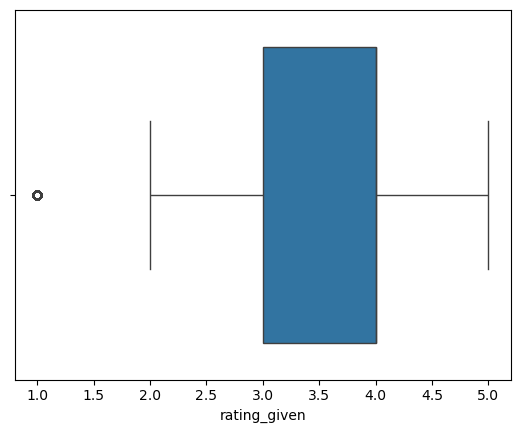

In [7]:
import seaborn as sns
sns.boxplot(x=df['rating_given'])

In [8]:
df['rating_given'] = df['rating_given'].fillna(df['rating_given'].median())

In [9]:
df['rating_given'].isnull().sum()

np.int64(0)

In [10]:
# Feature selection
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove('user_id')

print(numeric_features)

['age', 'app_version', 'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes', 'feature_clicks_per_session', 'notifications_opened_per_week', 'in_app_search_count', 'pages_viewed_per_session', 'crash_events_last_30_days', 'support_tickets_raised', 'days_since_last_login', 'ads_clicked_last_30_days', 'content_downloads', 'social_shares', 'rating_given', 'churn_risk_score', 'engagement_score', 'account_age_days']


In [11]:
df[numeric_features].isnull().sum()

age                              0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
dtype: int64

In [12]:
# Data Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_features])

In [13]:
# DBSCAN
from sklearn.cluster import DBSCAN

# DBSCAN model
dbscan = DBSCAN(eps=0.8, min_samples=10)

df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

# Check cluster distribution
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
-1    50000
Name: count, dtype: int64


In [14]:
# # Reult of dbcan
# Every user is labeled -1
# -1 in DBSCAN = Noise / Outlier
# The algorithm did not find any dense clusters
# So the conclusion is:
# DBSCAN could not detect meaningful clusters in this dataset.
# This is a valid result, not an error.DBSCAN was not suitable 
# for identifying user segments in this case.

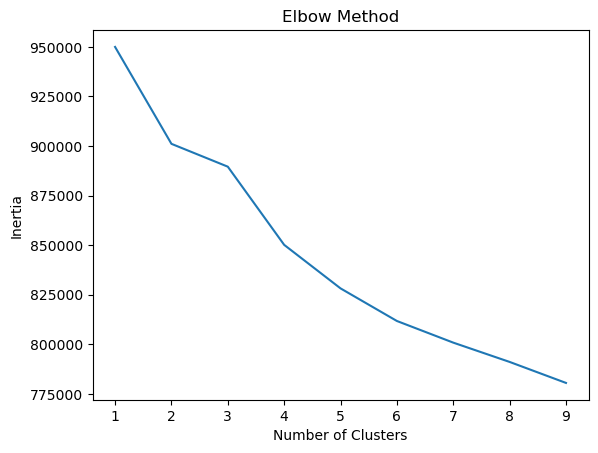

In [15]:
# Find Optimal Clusters
# Elbow Method
inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [16]:
# Apply K mean
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

In [17]:
# Add cluter to dataset
df['Cluster'] = clusters

df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,DBSCAN_Cluster,Cluster
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,9,5,2,4.0,0.31,55.79,1152,Referral,-1,0
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,8,3,3,3.0,0.87,82.39,1059,Email Campaign,-1,3
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,11,6,1,2.0,0.63,42.49,678,Google Ads,-1,0
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,6,3,1,3.0,0.43,62.81,92,Organic,-1,1
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,4,4,2,5.0,0.43,38.21,772,Email Campaign,-1,1


In [18]:
# Count users in each cluster
df['Cluster'].value_counts()

Cluster
1    18806
0    12283
3    10663
2     8248
Name: count, dtype: int64

In [19]:
# cluter profling
df_profile = df.drop(columns=['user_id'])

cluster_profile = df_profile.groupby('Cluster').mean(numeric_only=True)

cluster_profile

,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,DBSCAN_Cluster
Cluster,,,,,,,,,,,,,,,,,,,,
0,38.614671,1.478222,7.970528,13.163735,45.158397,12.016771,4.967679,3.993161,13.554669,1.285028,0.042009,22.168851,5.999104,2.997558,1.669869,3.662297,0.504745,65.029509,603.510624,-1.0
1,38.474848,1.479512,7.991545,13.185007,45.256115,12.039828,5.009890,4.001170,13.430288,0.000000,0.000000,21.943156,5.982718,3.013134,1.207008,3.676061,0.500660,64.865477,604.912581,-1.0
2,38.484360,1.467568,8.028249,13.172641,45.111084,11.955626,5.011397,3.999758,13.450170,0.299103,1.111785,22.038919,6.010063,2.987148,1.935863,3.671193,0.498889,64.829961,600.175073,-1.0
3,38.485511,1.474360,8.025509,13.054184,45.051442,12.010035,4.995123,4.001594,13.461409,0.152396,0.013786,22.054956,6.004033,3.000188,3.835225,3.656757,0.498142,65.055359,604.905186,-1.0


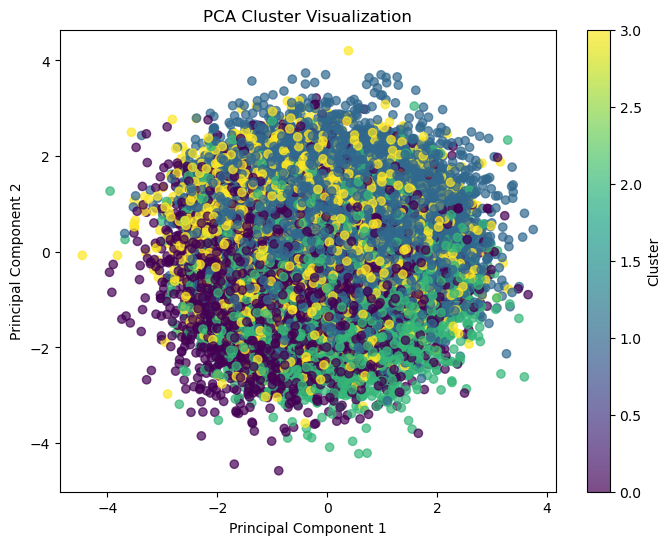

In [20]:
# pca vizual
numeric_features1 = df.select_dtypes(include=['int64','float64']).columns
X = df[numeric_features1].drop(columns=['user_id','Cluster'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Cluster Visualization")
plt.colorbar(scatter,label="Cluster")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.04384143671979046


In [22]:
df.groupby('Cluster')['engagement_score'].mean()
df['User_Category'] = df['Cluster'].map({
0:'Moderate Users',
1:'Low Users',
2:'Occasional Users',
3:'High Users'
})

In [23]:
df.to_csv("user_behavior_clusters.csv", index=False)

In [24]:
# Analytical task

In [25]:
# Extract Users for Each Category
high_users = df[df['User_Category'] == 'High Users']
moderate_users = df[df['User_Category'] == 'Moderate Users']
low_users = df[df['User_Category'] == 'Low Users']
occasional_users = df[df['User_Category'] == 'Occasional Users']

In [26]:
# count per category
user_counts = df['User_Category'].value_counts()

print(user_counts)



User_Category
Low Users           18806
Moderate Users      12283
High Users          10663
Occasional Users     8248
Name: count, dtype: int64


In [27]:
user_list=df.groupby('User_Category')['user_id'].apply(list).reset_index()
user_list.columns=['User_Category','user_id']
print(user_list)

      User_Category                                            user_id
0        High Users  [100001, 100007, 100014, 100016, 100022, 10002...
1         Low Users  [100003, 100004, 100005, 100006, 100009, 10001...
2    Moderate Users  [100000, 100002, 100010, 100015, 100017, 10002...
3  Occasional Users  [100008, 100013, 100028, 100041, 100048, 10005...


In [28]:
max_len=user_list['user_id'].apply(len).max()
user_ids_expanded=pd.DataFrame(user_list['user_id'].tolist(),index=user_list['User_Category'])
user_ids_expanded.to_csv('userBy_cluster.csv')                               

Cluster
1    18806
0    12283
3    10663
2     8248
Name: count, dtype: int64


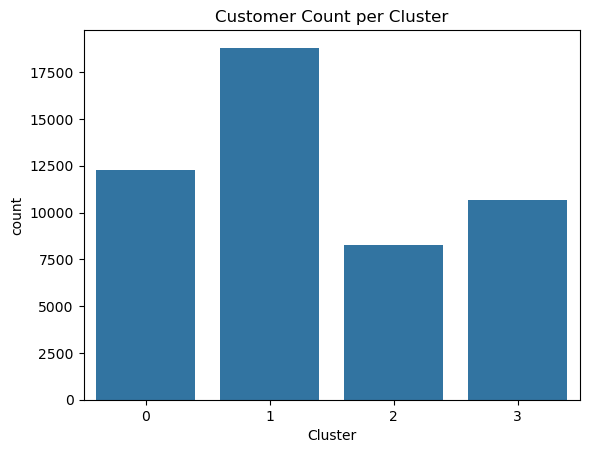

In [29]:
# Counted the Number of Customers in Each Group

cluster_counts = df['Cluster'].value_counts()
print(cluster_counts)

sns.countplot(x='Cluster', data=df)
plt.title("Customer Count per Cluster")
plt.show()

               user_id        age  app_version  sessions_per_week  \
Cluster                                                             
0        124922.139461  38.614671     1.478222           7.970528   
1        125029.397267  38.474848     1.479512           7.991545   
2        125032.681135  38.484360     1.467568           8.028249   
3        125010.218700  38.485511     1.474360           8.025509   

         avg_session_duration_min  daily_active_minutes  \
Cluster                                                   
0                       13.163735             45.158397   
1                       13.185007             45.256115   
2                       13.172641             45.111084   
3                       13.054184             45.051442   

         feature_clicks_per_session  notifications_opened_per_week  \
Cluster                                                              
0                         12.016771                       4.967679   
1                   

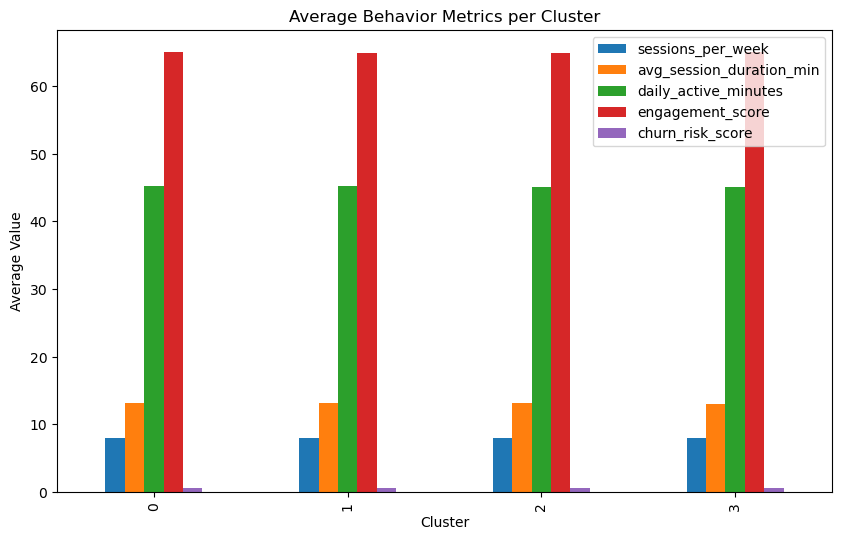

In [30]:
# Analyzed Average Engagement and Session Behavior per Cluster
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_profile)

cluster_profile[['sessions_per_week','avg_session_duration_min',
                 'daily_active_minutes','engagement_score',
                 'churn_risk_score']].plot(kind='bar', figsize=(10,6))

plt.title("Average Behavior Metrics per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.show()

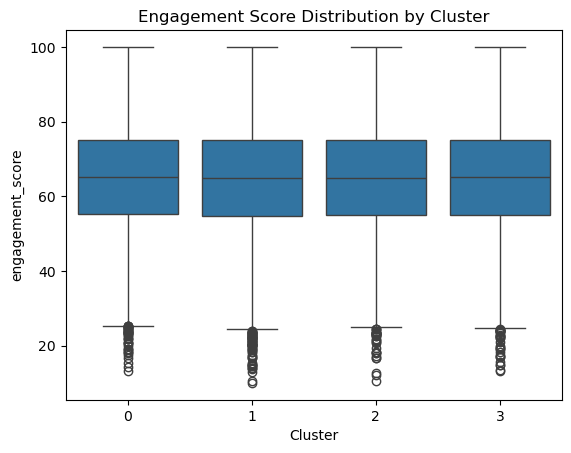

In [31]:
# Created Customer-Level Behavioral Profiles
sns.boxplot(x='Cluster', y='engagement_score', data=df)
plt.title("Engagement Score Distribution by Cluster")
plt.show()

In [46]:
# Group by User_Category and calculate mean of numeric features
customer_profiles = df.groupby('User_Category').mean(numeric_only=True)[['sessions_per_week','daily_active_minutes','feature_clicks_per_session','notifications_opened_per_week',
'in_app_search_count','pages_viewed_per_session','crash_events_last_30_days','ads_clicked_last_30_days','content_downloads','social_shares','rating_given','churn_risk_score','engagement_score']]

customer_profiles

,sessions_per_week,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score
User_Category,,,,,,,,,,,,,
High Users,8.025509,45.051442,12.010035,4.995123,4.001594,13.461409,0.152396,6.004033,3.000188,3.835225,3.656757,0.498142,65.055359
Low Users,7.991545,45.256115,12.039828,5.009890,4.001170,13.430288,0.000000,5.982718,3.013134,1.207008,3.676061,0.500660,64.865477
Moderate Users,7.970528,45.158397,12.016771,4.967679,3.993161,13.554669,1.285028,5.999104,2.997558,1.669869,3.662297,0.504745,65.029509
Occasional Users,8.028249,45.111084,11.955626,5.011397,3.999758,13.450170,0.299103,6.010063,2.987148,1.935863,3.671193,0.498889,64.829961


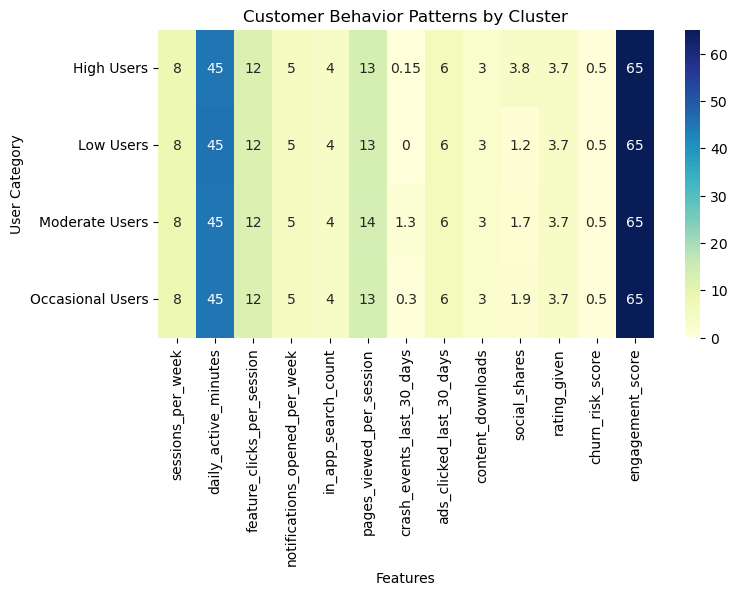

In [61]:
plt.figure(figsize=(8,4))

sns.heatmap(customer_profiles, annot=True, cmap="YlGnBu")

plt.title("Customer Behavior Patterns by Cluster")
plt.xlabel("Features")
plt.ylabel("User Category")
plt.show()

In [48]:
# ●	Identified high-value customers for loyalty and premium offers

high_value_customers = df[df['User_Category'] == 'High Users']

high_value_count = len(high_value_customers)


print("Number of High Value Users:", high_value_count)

Number of High Value Users: 10663


In [49]:
columns_for_analysis = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'ads_clicked_last_30_days',
    'content_downloads',
    'social_shares',
    'engagement_score',
    'churn_risk_score'
]

high_user_profile = high_value_customers[columns_for_analysis].mean()

print(high_user_profile)

sessions_per_week                 8.025509
avg_session_duration_min         13.054184
daily_active_minutes             45.051442
feature_clicks_per_session       12.010035
notifications_opened_per_week     4.995123
in_app_search_count               4.001594
pages_viewed_per_session         13.461409
ads_clicked_last_30_days          6.004033
content_downloads                 3.000188
social_shares                     3.835225
engagement_score                 65.055359
churn_risk_score                  0.498142
dtype: float64


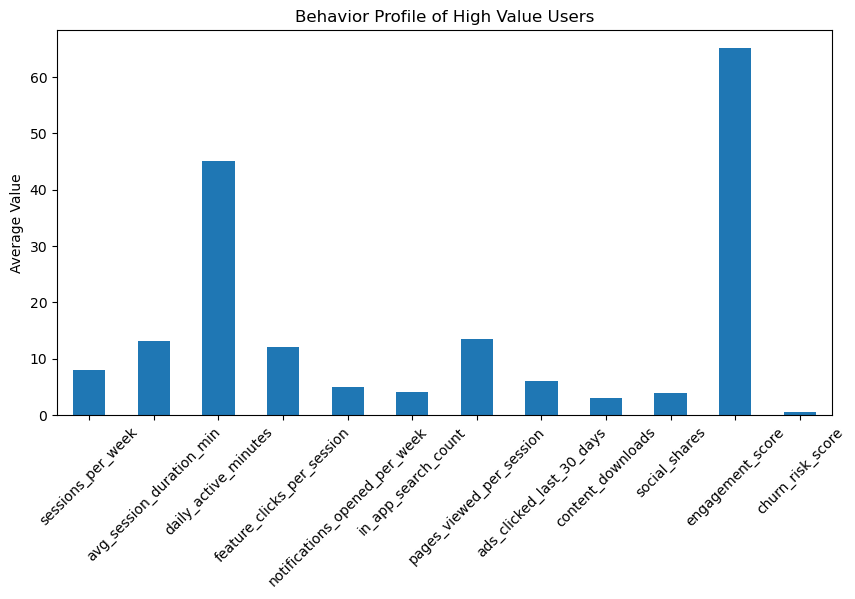

In [50]:
import matplotlib.pyplot as plt

high_user_profile.plot(kind='bar', figsize=(10,5))

plt.title("Behavior Profile of High Value Users")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.show()

In [51]:


df['At_Risk_Customer'] = (
    (df['engagement_score'] < 40) &
    (df['churn_risk_score'] > 0.6)
)

In [52]:

at_risk_users = df[df['At_Risk_Customer'] == True]

risk_user_count = len(at_risk_users)

print("Number of At-Risk Users:", risk_user_count)

Number of At-Risk Users: 966


In [53]:
at_risk_users[['user_id',
               'sessions_per_week',
               'engagement_score',
               'churn_risk_score',
               'days_since_last_login']].head()

,user_id,sessions_per_week,engagement_score,churn_risk_score,days_since_last_login
59,100059,8,39.56,0.95,22
113,100113,4,36.27,0.77,14
306,100306,6,37.91,0.78,39
411,100411,14,38.11,0.65,5
438,100438,11,36.17,0.85,28


In [54]:
risk_features = [
    'sessions_per_week',
    'daily_active_minutes',
    'engagement_score',
    'churn_risk_score',
    'days_since_last_login'
]

risk_behavior = at_risk_users[risk_features].mean()

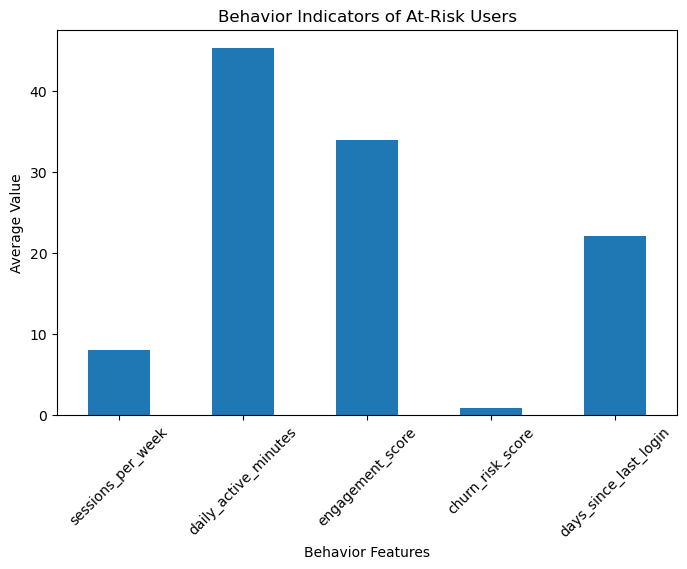

In [55]:
import matplotlib.pyplot as plt

risk_behavior.plot(kind='bar', figsize=(8,5))

plt.title("Behavior Indicators of At-Risk Users")
plt.xlabel("Behavior Features")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

In [56]:
# ●	Designed personalized engagement strategies for moderate users

moderate_users = df[df['User_Category'] == 'Moderate Users']
moderate_user_count = len(moderate_users)
print("Number of Moderate Users:", moderate_user_count)

Number of Moderate Users: 12283


In [57]:
moderate_features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'pages_viewed_per_session',
    'engagement_score'
]

moderate_profile = moderate_users[moderate_features].mean()

print(moderate_profile)

sessions_per_week                 7.970528
avg_session_duration_min         13.163735
daily_active_minutes             45.158397
feature_clicks_per_session       12.016771
notifications_opened_per_week     4.967679
pages_viewed_per_session         13.554669
engagement_score                 65.029509
dtype: float64


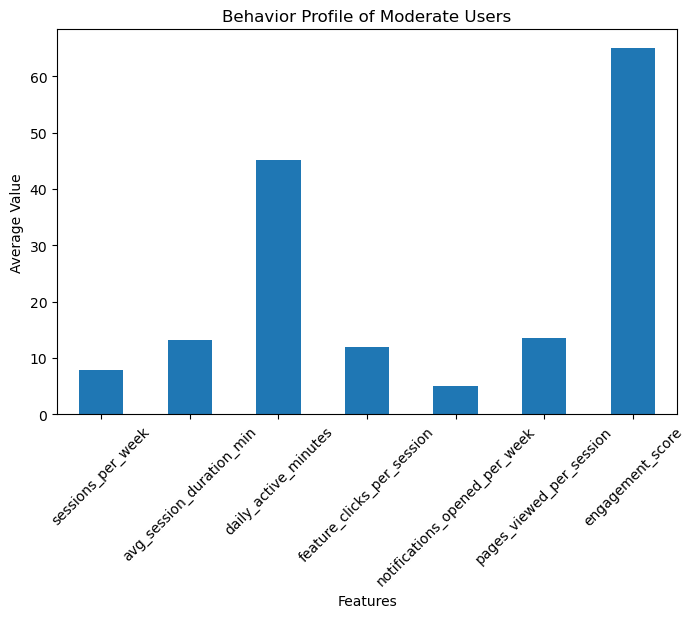

In [58]:
moderate_profile.plot(kind='bar', figsize=(8,5))
plt.title("Behavior Profile of Moderate Users")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

In [59]:


segment_summary = df.groupby('User_Category')[[
    'sessions_per_week',
    'daily_active_minutes',
    'engagement_score',
    'churn_risk_score'
]].mean()

segment_summary

,sessions_per_week,daily_active_minutes,engagement_score,churn_risk_score
User_Category,,,,
High Users,8.025509,45.051442,65.055359,0.498142
Low Users,7.991545,45.256115,64.865477,0.500660
Moderate Users,7.970528,45.158397,65.029509,0.504745
Occasional Users,8.028249,45.111084,64.829961,0.498889
